<a href="https://colab.research.google.com/github/JuanFerMC/Labs-Model-and-Sim-Sist/blob/main/Grupo2_Vinos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🟠 Grupo 2 — Diagnóstico de Subajuste
## Taller: Árboles de Decisión · Modelos y Simulación de Sistemas II
**Universidad de Antioquia · María Bernarda Salazar Sánchez, Ph.D.**

---
### 📋 Contexto
Un enólogo entrenó un árbol para clasificar vinos en **Alta calidad** o **Baja calidad** usando propiedades físico-químicas.  
El modelo tiene **72% de precisión en entrenamiento Y en prueba** — el enólogo cree que es "estable", pero en realidad el modelo es demasiado simple y no aprende la complejidad del problema.

**Variables predictoras:** acidez fija, acidez volátil, ácido cítrico, azúcar residual, cloruros, dióxido de azufre, densidad, pH, sulfatos, alcohol (10 variables).

**Variable objetivo:** `calidad_alta` (1 = alta calidad · 0 = baja calidad)

---
### 🎯 Tu misión (15 minutos)
1. Ejecuta las celdas y observa que **ambos errores son igualmente altos** (tren ≈ prueba ≈ 72%)
2. **Identifica el error:** ¿qué tan profundo es el árbol? ¿puede un árbol tan simple capturar 10 variables?
3. **Aplica corrección:** aumenta `max_depth` y reduce `min_impurity_decrease`
4. Usa la tabla de exploración para guiar tu elección
5. Prepara tu exposición respondiendo las preguntas al final

> 💡 **Pista:** Cuando Train ≈ prueba y ambos son bajos → subajuste. El modelo no tiene capacidad suficiente.


In [ ]:
# Configuración
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
PURPLE='#534AB7'; TEAL='#0F6E56'; RED='#A32D2D'; AMBER='#854F0B'

def metricas(clf, Xtr, Xte, ytr, yte, titulo=''):
    atr = clf.score(Xtr, ytr)
    ate = clf.score(Xte, yte)
    cv  = cross_val_score(clf, np.vstack([Xtr,Xte]),
                          np.concatenate([ytr,yte]), cv=5).mean()
    bre = atr - ate
    print(f"{'─'*52}")
    if titulo: print(f"  {titulo}")
    print(f"  Precisión entrenamiento : {atr:.3f}  ({atr*100:.1f}%)")
    print(f"  Precisión prueba        : {ate:.3f}  ({ate*100:.1f}%)")
    print(f"  CV-5fold  (promedio)    : {cv:.3f}")
    print(f"  Brecha Train-Test      : {bre:.3f}  ", end='')
    if bre > 0.12: print("SOBREAJUSTE")
    elif ate < 0.72: print("SUBAJUSTE")
    else: print("✅ OK")
    print(f"  Hojas / Profundidad     : {clf.get_n_leaves()} hojas · prof={clf.get_depth()}")
    print(f"{'─'*52}")
    return atr, ate

def comparar(clf_a, clf_b, Xte, yte, nombres=('Original','Corregido')):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, clf, nom, col in zip(axes,[clf_a,clf_b],nombres,[RED,TEAL]):
        cm = confusion_matrix(yte, clf.predict(Xte))
        ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f"{nom}\nPrecisión prueba: {clf.score(Xte,yte):.1%}",
                     color=col, fontweight='bold')
    plt.tight_layout(); plt.show()

print('✅ Listo para comenzar.')


✅ Listo para comenzar.


In [ ]:
# ── Datos (Wine dataset de sklearn) ───────────────────────────────
from sklearn.datasets import load_wine
wine = load_wine()
X = wine.data
y = (wine.target == 0).astype(int)   # clase 0 = alta calidad
feat = list(wine.feature_names)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3,
                                        random_state=42, stratify=y)
print(f"Dataset: {len(y)} vinos")
print(f"  Alta calidad  (y=1): {y.sum()} muestras  ({y.mean():.0%})")
print(f"  Baja calidad  (y=0): {(y==0).sum()} muestras")
print(f"  Variables predictoras: {len(feat)}")
pd.DataFrame(X[:3], columns=feat).round(2)


Dataset: 178 vinos
  Alta calidad  (y=1): 59 muestras  (33%)
  Baja calidad  (y=0): 119 muestras
  Variables predictoras: 13


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


📊 Árbol original:
────────────────────────────────────────────────────
  Original
  Precisión entrenamiento : 0.952  (95.2%)
  Precisión prueba        : 0.870  (87.0%)
  CV-5fold  (promedio)    : 0.910
  Brecha Train-Test      : 0.081  ✅ OK
  Hojas / Profundidad     : 2 hojas · prof=1
────────────────────────────────────────────────────


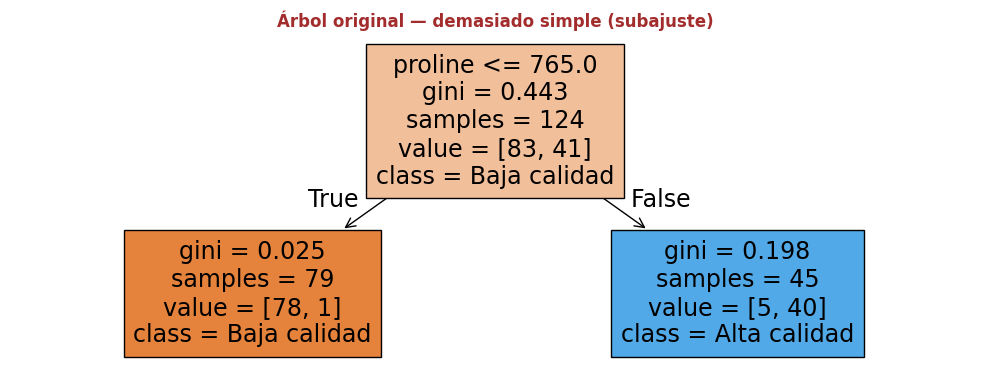


🔍 El árbol tiene solo 2 hoja(s).
   ¿Puede UNA sola pregunta clasificar vinos con 13 variables?

📈 Exploración: precisión según profundidad
   depth   Train    Test   hojas
       1   0.952   0.870       2
       2   0.992   0.926       4
       3   1.000   0.926       5
       4   1.000   0.926       5
       5   1.000   0.926       5
       6   1.000   0.926       5
       7   1.000   0.926       5
       8   1.000   0.926       5
       9   1.000   0.926       5
      10   1.000   0.926       5
      11   1.000   0.926       5


In [ ]:
# ── Árbol ORIGINAL — NO modificar esta celda ──────────────────────
arbol_orig = DecisionTreeClassifier(
    max_depth             = 1,
    min_impurity_decrease = 0.15,
    random_state          = 42
).fit(Xtr, ytr)

print("📊 Árbol original:")
metricas(arbol_orig, Xtr, Xte, ytr, yte, 'Original')

fig, ax = plt.subplots(figsize=(10, 4))
plot_tree(arbol_orig, feature_names=feat,
          class_names=['Baja calidad','Alta calidad'], filled=True, ax=ax)
ax.set_title('Árbol original — demasiado simple (subajuste)', color=RED, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n🔍 El árbol tiene solo", arbol_orig.get_n_leaves(), "hoja(s).")
print(f"   ¿Puede UNA sola pregunta clasificar vinos con {len(feat)} variables?")
print("\n📈 Exploración: precisión según profundidad")
print(f"  {'depth':>6}  {'Train':>6}  {'Test':>6}  {'hojas':>6}")
for d in range(1, 12):
    c = DecisionTreeClassifier(max_depth=d, random_state=42).fit(Xtr, ytr)
    print(f"  {d:>6}  {c.score(Xtr,ytr):>6.3f}  {c.score(Xte,yte):>6.3f}  {c.get_n_leaves():>6}")


---
### ✏️ Tu turno — Aumenta la capacidad del árbol
Modifica los parámetros marcados con 👈 basándote en la tabla de exploración.  
**No uses técnicas externas** — la solución debe venir solo del ajuste de hiperparámetros del árbol.

**Objetivo:** precisión prueba > 0.88  con  brecha train-prueba < 0.12


📊 Árbol corregido:
────────────────────────────────────────────────────
  Corregido
  Precisión entrenamiento : 0.992  (99.2%)
  Precisión prueba        : 0.926  (92.6%)
  CV-5fold  (promedio)    : 0.921
  Brecha Train-Test      : 0.066  ✅ OK
  Hojas / Profundidad     : 4 hojas · prof=2
────────────────────────────────────────────────────


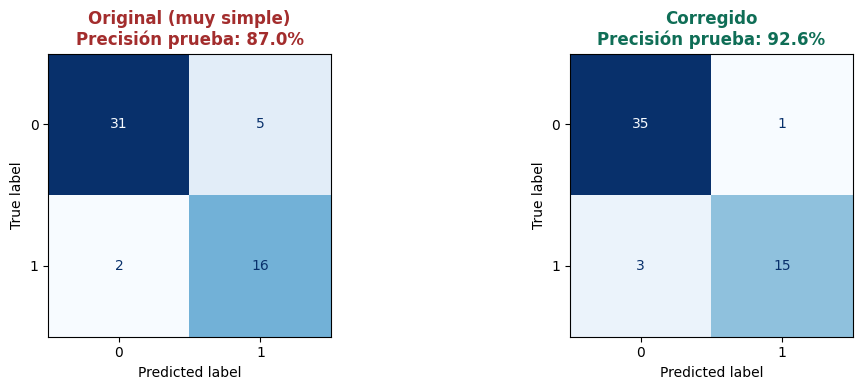

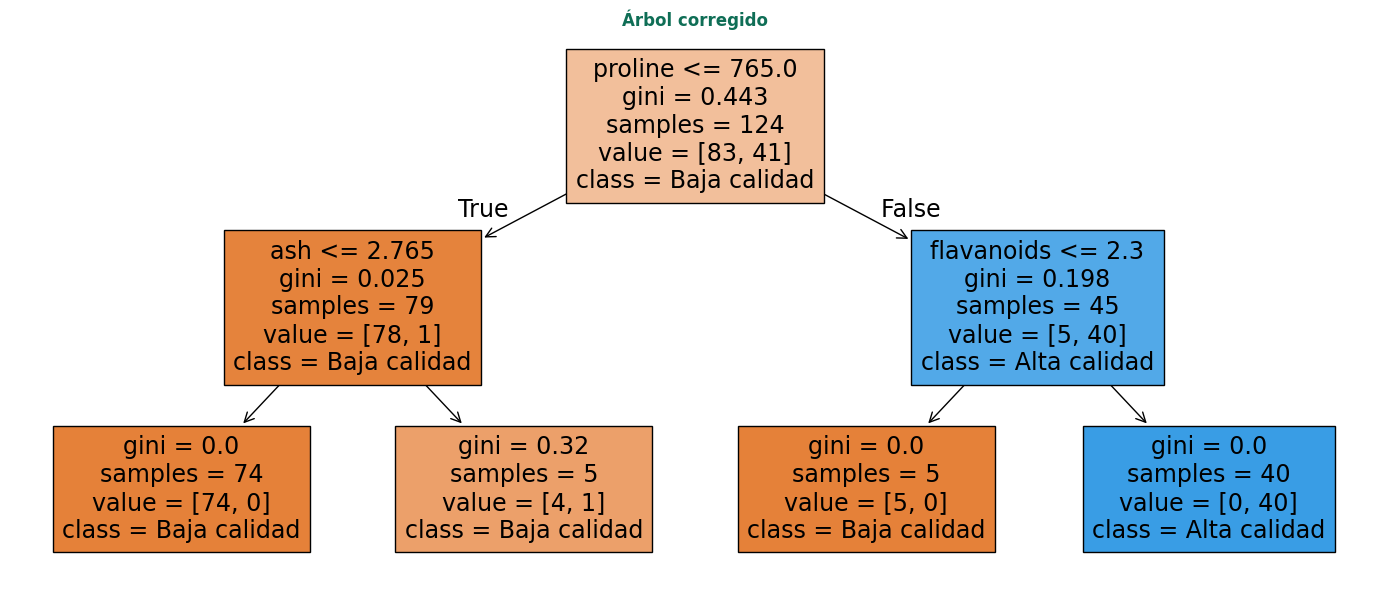

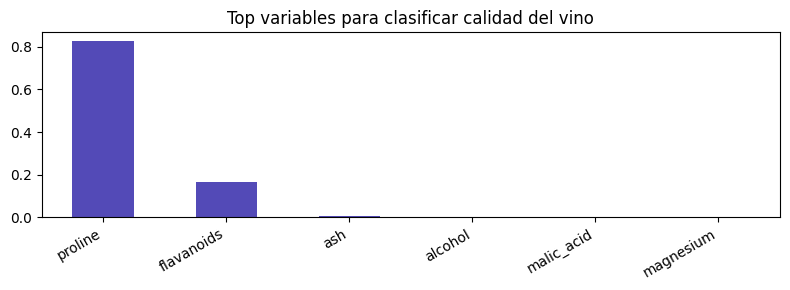

In [ ]:
# ── SOLUCIÓN — Ajusta estos parámetros ───────────────────────────
arbol_fix = DecisionTreeClassifier(
    max_depth             = 2,    # 👈 Cambiar según la tabla de exploración
    min_impurity_decrease = 0.00, # 👈 Reducir: probar 0.0, 0.01, 0.02, 0.05
    min_samples_leaf      = 5,    # 👈 Opcional: probar 3, 5
    random_state          = 42
).fit(Xtr, ytr)

print("📊 Árbol corregido:")
metricas(arbol_fix, Xtr, Xte, ytr, yte, 'Corregido')

comparar(arbol_orig, arbol_fix, Xte, yte,
         nombres=('Original (muy simple)','Corregido'))

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(arbol_fix, feature_names=feat,
          class_names=['Baja calidad','Alta calidad'], filled=True, ax=ax)
ax.set_title('Árbol corregido', color=TEAL, fontweight='bold')
plt.tight_layout(); plt.show()

pd.Series(arbol_fix.feature_importances_, index=feat).sort_values(
    ascending=False).head(6).plot(
    kind='bar', color=PURPLE, figsize=(8,3),
    title='Top variables para clasificar calidad del vino')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


---
### 📢 Preguntas orientadoras para la exposición
1. ¿Por qué ambos errores (tren y prueba) eran altos al mismo tiempo? ¿Qué nombre tiene ese fenómeno?
2. ¿Qué profundidad elegiste y cómo lo decidiste a partir de la tabla?
3. ¿En qué punto la tabla muestra que agregar más profundidad ya no ayuda? (sobreajuste incipiente)
4. ¿Qué propiedad del vino resultó más discriminante?
5. ¿Hay riesgo de sobreajuste en tu árbol corregido? ¿Cómo lo sabes?

---
*🌳 Taller · Árboles de Decisión · Modelos y Simulación II · Universidad de Antioquia*


1. los errores iniciales eran muy altos debido a que el arbol solo hacia 1 comparación maxima para poder dividirse, es decir, este arbol solo crecera hasta maximo un nivel lo que causa en un principio un sub ajuste ya que no puede identificar otras caracteristicas para predecir
2. Elegimos una profundidad optima de 2 / 3 niveles debido a que si usamos la tabla como referencia notamos una brecha menor a la

Juan Fernando Mona Cano

Camilo Andrés Pérez Padilla